In [4]:
import numpy as np
from scipy.optimize import minimize
import random

# --- Configuration & Parameters (Baseline from Calvano et al. 2020) ---
class Config:
    n = 2               # Number of firms
    c = 1.0             # Marginal cost
    a = 2.0             # Quality parameter (a - c = 1 implies a=2 given c=1)
    a0 = 0.0            # Outside good quality
    mu = 0.25           # Index of horizontal differentiation
    delta = 0.95        # Discount factor
    
    k = 1               # Memory length (1 period)
    m = 15              # Number of prices in the grid
    xi = 0.1            # Grid extension parameter
    
    alpha = 0.15        # Learning rate (typical value used in papers)
    beta = 4e-6         # Decay parameter for epsilon (e^-beta*t)
    
    T = 1500000          # Number of simulation periods (reduced for demonstration, paper uses more)

cfg = Config()

# --- 1. Economic Environment Functions ---

def get_demand(prices):
    """Calculates Logit demand for each firm given a list of prices."""
    # Denominator: sum(exp((a_j - p_j)/mu)) + exp(a0/mu)
    # We use a_i = a for all firms (symmetric)
    exp_terms = np.exp((cfg.a - np.array(prices)) / cfg.mu)
    outside_term = np.exp(cfg.a0 / cfg.mu)
    denominator = np.sum(exp_terms) + outside_term
    
    demands = exp_terms / denominator
    return demands

def get_profit(prices):
    """Calculates profit for all firms given current prices."""
    demands = get_demand(prices)
    profits = (np.array(prices) - cfg.c) * demands
    return profits

# --- 2. Grid Construction (Nash & Monopoly) ---

def solve_stage_game():
    """
    Computes the static Bertrand-Nash (pN) and Monopoly (pM) prices
    to define the boundaries of the action space.
    """
    # 1. Find Monopoly Price (Maximize joint profit)
    # Symmetry assumption: p1 = p2 = p
    def neg_joint_profit(p):
        # p is a scalar here
        p_vec = [p[0]] * cfg.n
        return -np.sum(get_profit(p_vec))

    res_monopoly = minimize(neg_joint_profit, x0=[cfg.c + 1.0], bounds=[(cfg.c, 10)])
    pM = res_monopoly.x[0]

    # 2. Find Bertrand-Nash Price (Fixed point of best response)
    # Maximize profit_i given p_j is fixed.
    def neg_own_profit(pi, p_competitors):
        # Construct full price vector
        all_prices = np.insert(p_competitors, 0, pi) 
        return -get_profit(all_prices)[0] # Profit of firm 0

    # Iteratively find Nash (simple best response dynamics for solving)
    pN = pM # Start high
    for _ in range(50):
        # Optimize p1 given p2=pN (symmetry)
        res_nash = minimize(neg_own_profit, x0=[pN], args=([pN]*(cfg.n-1),), bounds=[(cfg.c, 10)])
        pN = res_nash.x[0]
        
    return pN, pM

pN, pM = solve_stage_game()
print(f"Static Nash Price (pN): {pN:.4f}")
print(f"Monopoly Price (pM): {pM:.4f}")

# Define the Action Space (Price Grid)
# Interval: [pN - xi(pM - pN), pM + xi(pM - pN)]
interval_range = pM - pN
lower_bound = pN - cfg.xi * interval_range
upper_bound = pM + cfg.xi * interval_range
action_space = np.linspace(lower_bound, upper_bound, cfg.m)

print(f"Action Space: {np.round(action_space, 4)}")

# --- 3. Q-Learning Agent ---

class QAgent:
    def __init__(self, n_actions, n_states):
        self.n_actions = n_actions
        # Q-matrix: rows=states, cols=actions
        self.Q = np.zeros((n_states, n_actions))
        
        # Initialization logic from Eq (8):
        # Q values initialized to discounted payoff if opponents randomize uniformly.
        # (Simplified here to explicit average calculation for exact replication)
        self.initialize_Q_values()

    def initialize_Q_values(self):
        # Average profit of taking action 'a' against random opponents
        # For every action index 'a_idx':
        for a_idx in range(self.n_actions):
            p_i = action_space[a_idx]
            expected_profit = 0
            
            # Loop over all possible opponent actions (assuming n=2 for simplicity in init)
            for opp_idx in range(self.n_actions):
                p_opp = action_space[opp_idx]
                # Compute profit for firm 0
                profs = get_profit([p_i, p_opp])
                expected_profit += profs[0]
            
            avg_profit = expected_profit / self.n_actions
            # Set initial Q value for all states
            self.Q[:, a_idx] = avg_profit / (1 - cfg.delta)

    def select_action(self, state_idx, epsilon):
        """Epsilon-greedy action selection."""
        if random.random() < epsilon:
            return random.randint(0, self.n_actions - 1)
        else:
            # Greedy: choose action with max Q-value
            # Break ties by choosing the lowest price (optional paper detail, often random)
            # We use np.argmax which takes the first occurrence (lowest index = lowest price)
            return np.argmax(self.Q[state_idx])

    def update(self, state_idx, action_idx, reward, next_state_idx):
        """Q-learning update rule."""
        max_next_Q = np.max(self.Q[next_state_idx])
        current_Q = self.Q[state_idx, action_idx]
        
        # Bellman Equation
        new_Q = (1 - cfg.alpha) * current_Q + \
                cfg.alpha * (reward + cfg.delta * max_next_Q)
        
        self.Q[state_idx, action_idx] = new_Q

# --- 4. Simulation Loop ---

# Setup Agents
num_states = cfg.m ** (cfg.n * cfg.k) # m^(n*k)
agents = [QAgent(cfg.m, num_states) for _ in range(cfg.n)]

# Helper to map memory (prices) to a single state integer
# State is tuple of past prices from all firms.
# For n=2, k=1: state = (p1_prev_idx, p2_prev_idx)
def get_state_index(prev_action_indices):
    # prev_action_indices is a list [idx_firm1, idx_firm2]
    # Map to 0..224
    return prev_action_indices[0] * cfg.m + prev_action_indices[1]

# Initialize State (Random prices to start)
initial_actions = [random.randint(0, cfg.m - 1) for _ in range(cfg.n)]
current_state_idx = get_state_index(initial_actions)

history_avg_prices = []


Static Nash Price (pN): 1.4729
Monopoly Price (pM): 1.9250
Action Space: [1.4277 1.4665 1.5052 1.544  1.5827 1.6215 1.6602 1.6989 1.7377 1.7764
 1.8152 1.8539 1.8927 1.9314 1.9702]


In [5]:

print(f"\nStarting Simulation for {cfg.T} periods...")

for t in range(cfg.T):
    # 1. Calculate Epsilon (decaying exploration)
    epsilon = np.exp(-cfg.beta * t)
    
    # 2. Agents choose actions
    actions_indices = [agent.select_action(current_state_idx, epsilon) for agent in agents]
    chosen_prices = [action_space[idx] for idx in actions_indices]
    
    # 3. Compute Rewards (Profits)
    rewards = get_profit(chosen_prices)
    
    # 4. Determine Next State
    next_state_idx = get_state_index(actions_indices)
    
    # 5. Update Q-matrices
    for i, agent in enumerate(agents):
        agent.update(current_state_idx, actions_indices[i], rewards[i], next_state_idx)
        
    # 6. Transition
    current_state_idx = next_state_idx
    
    # Monitoring
    if t % 50000 == 0:
        avg_p = np.mean(chosen_prices)
        print(f"Episode {t}: Avg Price = {avg_p:.4f}, Epsilon = {epsilon:.4f}")
    
    # Store last 1000 prices for final stats
    if t > cfg.T - 1000:
        history_avg_prices.append(np.mean(chosen_prices))

# --- 5. Results ---
final_avg_price = np.mean(history_avg_prices)
print(f"\nSimulation Complete.")
print(f"Final Average Price: {final_avg_price:.4f}")
print(f"Collusion Index: {(final_avg_price - pN) / (pM - pN):.4f}") 
# (0 = Competitive, 1 = Monopoly)


Starting Simulation for 1500000 periods...
Episode 0: Avg Price = 1.6021, Epsilon = 1.0000
Episode 50000: Avg Price = 1.7571, Epsilon = 0.8187
Episode 100000: Avg Price = 1.7183, Epsilon = 0.6703
Episode 150000: Avg Price = 1.5246, Epsilon = 0.5488
Episode 200000: Avg Price = 1.4858, Epsilon = 0.4493
Episode 250000: Avg Price = 1.6796, Epsilon = 0.3679
Episode 300000: Avg Price = 1.6215, Epsilon = 0.3012
Episode 350000: Avg Price = 1.7764, Epsilon = 0.2466
Episode 400000: Avg Price = 1.6989, Epsilon = 0.2019
Episode 450000: Avg Price = 1.5440, Epsilon = 0.1653
Episode 500000: Avg Price = 1.6989, Epsilon = 0.1353
Episode 550000: Avg Price = 1.6602, Epsilon = 0.1108
Episode 600000: Avg Price = 1.6796, Epsilon = 0.0907
Episode 650000: Avg Price = 1.5633, Epsilon = 0.0743
Episode 700000: Avg Price = 1.5633, Epsilon = 0.0608
Episode 750000: Avg Price = 1.6021, Epsilon = 0.0498
Episode 800000: Avg Price = 1.7764, Epsilon = 0.0408
Episode 850000: Avg Price = 1.5246, Epsilon = 0.0334
Episode 

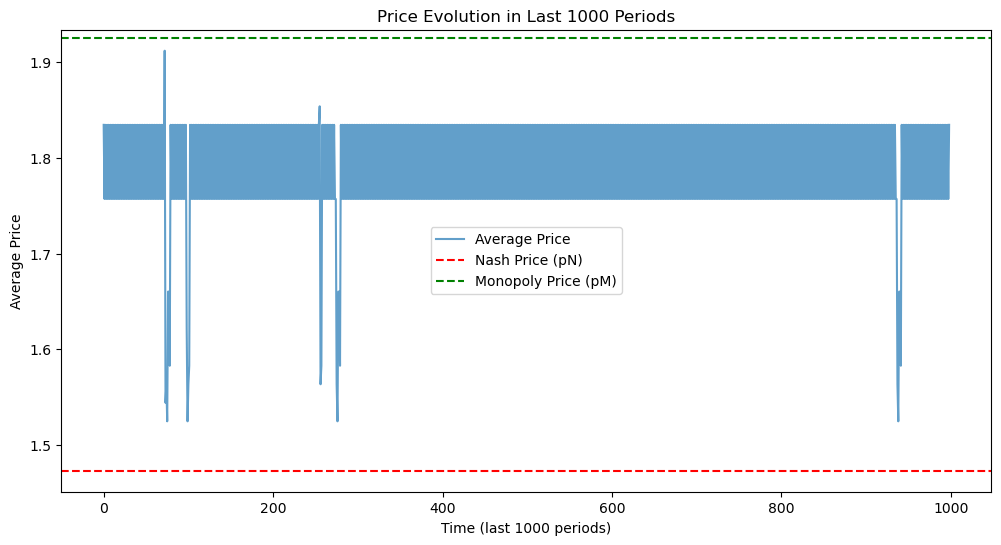

In [6]:
# Visualization: price history with mono and nash lines
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(history_avg_prices, label='Average Price', alpha=0.7)
plt.axhline(y=pN, color='r', linestyle='--', label='Nash Price (pN)')
plt.axhline(y=pM, color='g', linestyle='--', label='Monopoly Price (pM)')
plt.xlabel('Time (last 1000 periods)')
plt.ylabel('Average Price')
plt.title('Price Evolution in Last 1000 Periods')
plt.legend()
plt.show()